# Results by Research Question

This notebook presents all available validation-set results organised under the thesis research questions.

**Models and conditions:**
- `unet_base` — 3D U-Net, Sigmoid activation, no geometric channels
- `dgan_base` — DoseGAN, Sigmoid activation, no geometric channels
- `unet_geom` — 3D U-Net, Sigmoid activation, with geometric channels
- `dgan_geom` — DoseGAN, Sigmoid activation, with geometric channels

**Data:** 5-fold cross-validation on LUND-PROBE (432 patients; 73–74 val patients per fold).

---

**Research question structure (confirmed 2026-06-01):**

| RQ | Question | Primary metrics |
|---|---|---|
| **SRQ 1** | How do 3D U-Net and DoseGAN compare on voxel-wise dose accuracy? | body_MAE, body_RMSE, boundary_MAE |
| **SRQ 2** | Do geometric input channels improve prediction, and for whom? | Δ body_MAE, Δ boundary_MAE (geom − baseline) |
| **SRQ 3** | How accurate are predicted DVH endpoints for clinical structures? | D95_err, Dmean_err, D0.1cc_err; gamma pass rate |

Supporting analyses: Sigmoid vs Tanh ablation (activation choice justification), acquisition-group robustness (Inv1 finding).

## Setup

In [1]:
import sys, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

sys.path.insert(0, '/gpfs/scratch1/shared/akhalil/data/thesis-doseprediction')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

COLORS = {
    'unet_base': '#2196F3',
    'dgan_base': '#FF5722',
    'unet_geom': '#64B5F6',
    'dgan_geom': '#FF8A65',
    'unet_tanh': '#90CAF9',
    'dgan_tanh': '#FFCCBC',
}
LABELS = {
    'unet_base': 'U-Net (baseline)',
    'dgan_base': 'DoseGAN (baseline)',
    'unet_geom': 'U-Net + geom',
    'dgan_geom': 'DoseGAN + geom',
    'unet_tanh': 'U-Net (Tanh)',
    'dgan_tanh': 'DoseGAN (Tanh)',
}

EVAL_DIR     = '/gpfs/scratch1/shared/akhalil/data/thesis-doseprediction/outputs/evaluation/'
BASELINE_DIR = EVAL_DIR + ''
ABLATION_DIR = EVAL_DIR + 'archived_ablations/'

def load_condition(pattern, label):
    dfs = []
    for p in sorted(glob.glob(pattern)):
        df = pd.read_csv(p)
        df['_fold'] = int(p.split('fold')[1].split('_')[0])
        df['condition'] = label
        if 'model' in df.columns:
            df = df.drop(columns=['model'])
        dfs.append(df)
    if not dfs:
        print(f'WARNING: no files found for pattern {pattern}')
        return pd.DataFrame()
    return pd.concat(dfs, ignore_index=True)

unet_base = load_condition(BASELINE_DIR + 'unet3d_ch32_sigmoid_snellius_fold*_val.csv',  'unet_base')
dgan_base = load_condition(BASELINE_DIR + 'dosegan_ngf32_sigmoid_snellius_fold*_val.csv', 'dgan_base')
unet_geom = load_condition(EVAL_DIR     + 'unet3d_ch32_sigmoid_geom_snellius_fold*_val.csv',  'unet_geom')
dgan_geom = load_condition(EVAL_DIR     + 'dosegan_ngf32_sigmoid_geom_snellius_fold*_val.csv', 'dgan_geom')
unet_tanh = load_condition(ABLATION_DIR + 'unet3d_ch32_tanh_snellius_fold*_val.csv',  'unet_tanh')
dgan_tanh = load_condition(ABLATION_DIR + 'dosegan_ngf32_tanh_snellius_fold*_val.csv', 'dgan_tanh')

all_df = pd.concat([unet_base, dgan_base, unet_geom, dgan_geom], ignore_index=True)

print('Patients per condition:')
print(all_df.groupby('condition')['patient_id'].count().to_string())
print(f'\nFolds: {sorted(all_df["_fold"].unique())}')

Patients per condition:
condition
dgan_base    367
dgan_geom    368
unet_base    367
unet_geom    367

Folds: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


In [2]:
def fold_summary(df, col):
    """Fold-mean ± fold-std string."""
    m = df.groupby('_fold')[col].mean()
    return f'{m.mean():.3f} ± {m.std():.3f}'

def fold_mean(df, col):
    return df.groupby('_fold')[col].mean().mean()

def fold_std(df, col):
    return df.groupby('_fold')[col].mean().std()

def summary_table(conditions, metrics):
    """Build fold-mean ± fold-std table for given conditions and metrics."""
    rows = []
    for label, df in conditions:
        row = {'condition': label}
        for col in metrics:
            if col in df.columns:
                row[col] = fold_summary(df, col)
            else:
                row[col] = 'N/A'
        rows.append(row)
    return pd.DataFrame(rows).set_index('condition')

print('Helper functions defined.')

Helper functions defined.


---
## SRQ 1 — 3D U-Net vs DoseGAN: voxel-wise dose accuracy

**Question:** How do the two model architectures compare on voxel-wise dose accuracy under identical data, splits, and training conditions?

**Metrics:** body MAE (Gy), body RMSE (Gy), boundary MAE for PTV / Rectum / Bladder (Gy).  
**Comparison:** `unet_base` vs `dgan_base` (Sigmoid, no geometric channels, 5 folds).

In [3]:
srq1_metrics = [
    'body_MAE_Gy', 'body_RMSE_Gy',
    'ptv_MAE_Gy', 'rectum_MAE_Gy', 'bladder_MAE_Gy',
    'boundary_MAE_ptv_Gy', 'boundary_MAE_rectum_Gy', 'boundary_MAE_bladder_Gy',
]

pd.set_option('display.max_colwidth', 22)
tbl = summary_table(
    [('U-Net (baseline)', unet_base), ('DoseGAN (baseline)', dgan_base)],
    srq1_metrics
)
print('SRQ 1 — Voxel-wise accuracy (fold-mean ± fold-std, 5 folds)')
display(tbl)

SRQ 1 — Voxel-wise accuracy (fold-mean ± fold-std, 5 folds)


,body_MAE_Gy,body_RMSE_Gy,ptv_MAE_Gy,rectum_MAE_Gy,bladder_MAE_Gy,boundary_MAE_ptv_Gy,boundary_MAE_rectum_Gy,boundary_MAE_bladder_Gy
condition,,,,,,,,
U-Net (baseline),0.861 ± 0.026,1.514 ± 0.038,0.515 ± 0.123,1.840 ± 0.126,1.386 ± 0.062,1.577 ± 0.080,1.381 ± 0.061,1.107 ± 0.039
DoseGAN (baseline),0.868 ± 0.035,1.522 ± 0.045,0.474 ± 0.121,1.844 ± 0.120,1.432 ± 0.090,1.573 ± 0.072,1.398 ± 0.079,1.127 ± 0.052


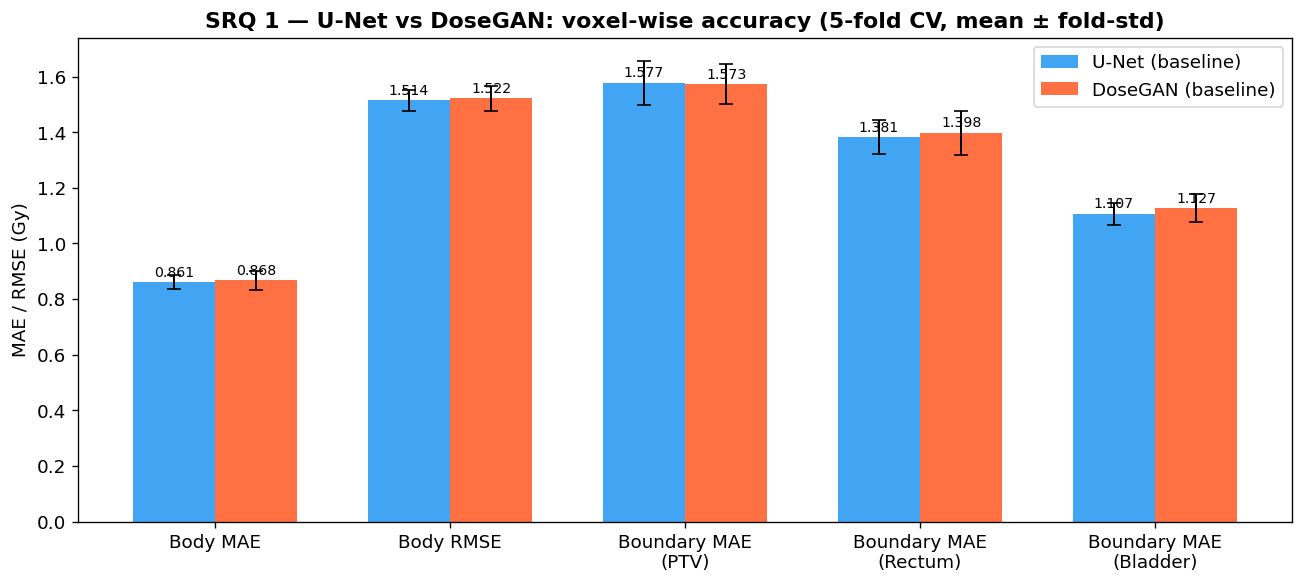

In [4]:
# Bar chart: body MAE and boundary MAE side by side
plot_metrics = [
    ('body_MAE_Gy',             'Body MAE'),
    ('body_RMSE_Gy',            'Body RMSE'),
    ('boundary_MAE_ptv_Gy',     'Boundary MAE\n(PTV)'),
    ('boundary_MAE_rectum_Gy',  'Boundary MAE\n(Rectum)'),
    ('boundary_MAE_bladder_Gy', 'Boundary MAE\n(Bladder)'),
]

x = np.arange(len(plot_metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))

for i, (cond, df, color) in enumerate([
        ('unet_base', unet_base, COLORS['unet_base']),
        ('dgan_base', dgan_base, COLORS['dgan_base'])
]):
    means = [fold_mean(df, col) for col, _ in plot_metrics]
    stds  = [fold_std(df, col)  for col, _ in plot_metrics]
    offset = (i - 0.5) * width
    bars = ax.bar(x + offset, means, width, label=LABELS[cond],
                  color=color, alpha=0.85, yerr=stds, capsize=4,
                  error_kw={'linewidth': 1.2})
    for bar, val in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8.5)

ax.set_xticks(x)
ax.set_xticklabels([label for _, label in plot_metrics])
ax.set_ylabel('MAE / RMSE (Gy)')
ax.set_title('SRQ 1 — U-Net vs DoseGAN: voxel-wise accuracy (5-fold CV, mean ± fold-std)',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

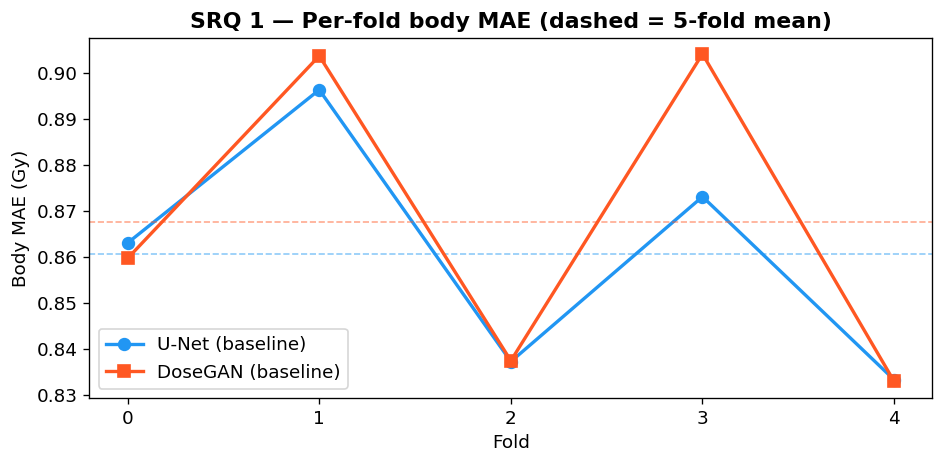

U-Net lower than DoseGAN on each fold:
  Fold 0: U-Net=0.8630  DoseGAN=0.8597  Δ=-0.0033  (DoseGAN lower)
  Fold 1: U-Net=0.8963  DoseGAN=0.9036  Δ=+0.0074  (U-Net lower)
  Fold 2: U-Net=0.8372  DoseGAN=0.8374  Δ=+0.0002  (U-Net lower)
  Fold 3: U-Net=0.8730  DoseGAN=0.9040  Δ=+0.0310  (U-Net lower)
  Fold 4: U-Net=0.8333  DoseGAN=0.8329  Δ=-0.0003  (DoseGAN lower)


In [5]:
# Per-fold body MAE — shows fold variance and consistency of direction
fig, ax = plt.subplots(figsize=(8, 4))

for cond, df, color, marker in [
        ('unet_base', unet_base, COLORS['unet_base'], 'o'),
        ('dgan_base', dgan_base, COLORS['dgan_base'], 's')
]:
    fold_means = df.groupby('_fold')['body_MAE_Gy'].mean()
    ax.plot(fold_means.index, fold_means.values, marker=marker, color=color,
            linewidth=2, markersize=7, label=LABELS[cond])
    ax.axhline(fold_means.mean(), color=color, linewidth=1, linestyle='--', alpha=0.5)

ax.set_xlabel('Fold')
ax.set_ylabel('Body MAE (Gy)')
ax.set_title('SRQ 1 — Per-fold body MAE (dashed = 5-fold mean)', fontweight='bold')
ax.set_xticks([0, 1, 2, 3, 4])
ax.legend()
plt.tight_layout()
plt.show()

# Check whether U-Net is lower on every fold
u_folds = unet_base.groupby('_fold')['body_MAE_Gy'].mean()
d_folds = dgan_base.groupby('_fold')['body_MAE_Gy'].mean()
print('U-Net lower than DoseGAN on each fold:')
for fold in range(5):
    diff = d_folds[fold] - u_folds[fold]
    print(f'  Fold {fold}: U-Net={u_folds[fold]:.4f}  DoseGAN={d_folds[fold]:.4f}  '
          f'Δ={diff:+.4f}  ({"U-Net lower" if diff > 0 else "DoseGAN lower"})')

In [6]:
# Statistical comparison on paired per-patient body_MAE
# Pair on patient_id (both models evaluated on the same patients)
paired = unet_base[['patient_id', 'body_MAE_Gy']].merge(
    dgan_base[['patient_id', 'body_MAE_Gy']], on='patient_id', suffixes=('_unet', '_dgan')
)
stat, pval = stats.wilcoxon(paired['body_MAE_Gy_unet'], paired['body_MAE_Gy_dgan'])
print(f'Wilcoxon signed-rank test (paired per-patient body MAE):')
print(f'  n = {len(paired)} patients')
print(f'  U-Net mean = {paired["body_MAE_Gy_unet"].mean():.4f} Gy')
print(f'  DoseGAN mean = {paired["body_MAE_Gy_dgan"].mean():.4f} Gy')
print(f'  Statistic = {stat:.1f},  p = {pval:.4f}')
print(f'  U-Net lower on {(paired["body_MAE_Gy_unet"] < paired["body_MAE_Gy_dgan"]).sum()}/{len(paired)} patients')

Wilcoxon signed-rank test (paired per-patient body MAE):
  n = 367 patients
  U-Net mean = 0.8607 Gy
  DoseGAN mean = 0.8676 Gy
  Statistic = 30318.0,  p = 0.0902
  U-Net lower on 191/367 patients


---
## SRQ 2 — Effect of geometric input channels

**Question:** Do geometric channels (distance maps, direction vectors) improve dose prediction, and which patients or structures benefit?

**Design:** Compare baseline vs geom for each model separately. Primary metric: body MAE; secondary: boundary MAE.  
**Key question:** Nika (Nika's DoseGNN work) concluded geometric channels did not help based on body MAE alone. Does the full metric suite agree?

In [7]:
srq2_metrics = [
    'body_MAE_Gy', 'body_RMSE_Gy',
    'boundary_MAE_ptv_Gy', 'boundary_MAE_rectum_Gy', 'boundary_MAE_bladder_Gy',
]

tbl2 = summary_table(
    [
        ('U-Net baseline',  unet_base),
        ('U-Net + geom',    unet_geom),
        ('DoseGAN baseline', dgan_base),
        ('DoseGAN + geom',  dgan_geom),
    ],
    srq2_metrics
)
print('SRQ 2 — Baseline vs geometric channels (fold-mean ± fold-std)')
display(tbl2)

SRQ 2 — Baseline vs geometric channels (fold-mean ± fold-std)


,body_MAE_Gy,body_RMSE_Gy,boundary_MAE_ptv_Gy,boundary_MAE_rectum_Gy,boundary_MAE_bladder_Gy
condition,,,,,
U-Net baseline,0.861 ± 0.026,1.514 ± 0.038,1.577 ± 0.080,1.381 ± 0.061,1.107 ± 0.039
U-Net + geom,0.839 ± 0.031,1.523 ± 0.042,1.682 ± 0.149,1.453 ± 0.099,1.157 ± 0.083
DoseGAN baseline,0.868 ± 0.035,1.522 ± 0.045,1.573 ± 0.072,1.398 ± 0.079,1.127 ± 0.052
DoseGAN + geom,0.868 ± 0.050,1.574 ± 0.096,1.637 ± 0.028,1.440 ± 0.017,1.156 ± 0.032


In [8]:
# Delta table: geom - baseline for each metric and model
print('SRQ 2 — Delta (geom − baseline), fold-mean ± fold-std')
print('Negative = improvement with geom channels\n')

rows = []
for model_label, base_df, geom_df in [
        ('U-Net',   unet_base, unet_geom),
        ('DoseGAN', dgan_base, dgan_geom)
]:
    row = {'model': model_label}
    for col in srq2_metrics:
        if col not in base_df.columns or col not in geom_df.columns:
            row[col] = 'N/A'
            continue
        base_fold = base_df.groupby('_fold')[col].mean()
        geom_fold = geom_df.groupby('_fold')[col].mean()
        delta_fold = geom_fold - base_fold
        row[col] = f'{delta_fold.mean():+.3f} ± {delta_fold.std():.3f}'
    rows.append(row)

display(pd.DataFrame(rows).set_index('model'))

SRQ 2 — Delta (geom − baseline), fold-mean ± fold-std
Negative = improvement with geom channels



,body_MAE_Gy,body_RMSE_Gy,boundary_MAE_ptv_Gy,boundary_MAE_rectum_Gy,boundary_MAE_bladder_Gy
model,,,,,
U-Net,-0.021 ± 0.013,+0.009 ± 0.030,+0.105 ± 0.152,+0.071 ± 0.114,+0.051 ± 0.106
DoseGAN,+0.000 ± 0.027,+0.052 ± 0.061,+0.064 ± 0.070,+0.042 ± 0.075,+0.029 ± 0.072


In [9]:
# Patient-level delta: who benefits, who regresses?
un_delta = unet_base[['patient_id','acquisition_group','body_MAE_Gy']].merge(
    unet_geom[['patient_id','body_MAE_Gy']], on='patient_id', suffixes=('_base','_geom'))
un_delta['delta'] = un_delta['body_MAE_Gy_geom'] - un_delta['body_MAE_Gy_base']

dg_delta = dgan_base[['patient_id','acquisition_group','body_MAE_Gy']].merge(
    dgan_geom[['patient_id','body_MAE_Gy']], on='patient_id', suffixes=('_base','_geom'))
dg_delta['delta'] = dg_delta['body_MAE_Gy_geom'] - dg_delta['body_MAE_Gy_base']

print('Patient-level geom delta (negative = geom improves body MAE):\n')
for label, delta_df in [('U-Net', un_delta), ('DoseGAN', dg_delta)]:
    n_total   = len(delta_df)
    n_improve = (delta_df['delta'] < 0).sum()
    print(f'{label}:')
    print(f'  Improves: {n_improve}/{n_total} patients ({n_improve/n_total*100:.0f}%)')
    print(f'  Mean Δ:   {delta_df["delta"].mean():+.4f} Gy')
    print(f'  Max improvement: {delta_df["delta"].min():+.3f} Gy')
    print(f'  Max regression:  {delta_df["delta"].max():+.3f} Gy')
    print()

Patient-level geom delta (negative = geom improves body MAE):

U-Net:
  Improves: 195/367 patients (53%)
  Mean Δ:   -0.0212 Gy
  Max improvement: -0.467 Gy
  Max regression:  +0.423 Gy

DoseGAN:
  Improves: 153/367 patients (42%)
  Mean Δ:   +0.0006 Gy
  Max improvement: -0.588 Gy
  Max regression:  +0.523 Gy



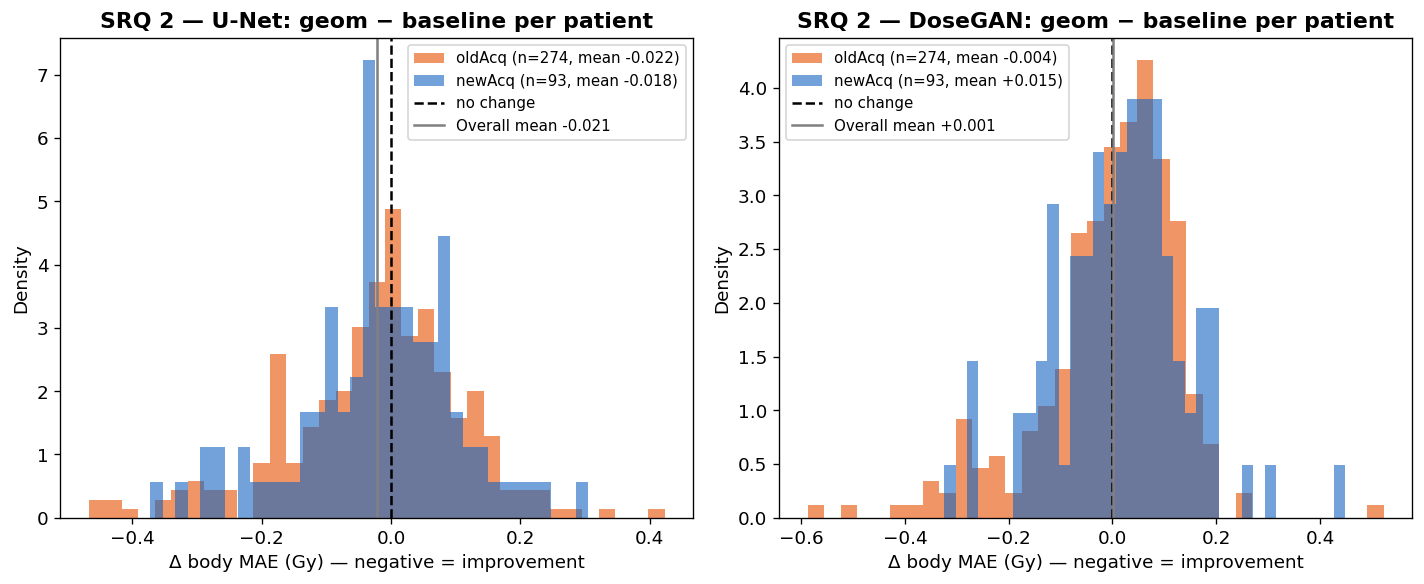

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (delta_df, model_label, base_color, geom_color) in zip(axes, [
    (un_delta, 'U-Net',   COLORS['unet_base'], COLORS['unet_geom']),
    (dg_delta, 'DoseGAN', COLORS['dgan_base'], COLORS['dgan_geom']),
]):
    for grp, color in [('oldAcq', '#E65100'), ('newAcq', '#1565C0')]:
        vals = delta_df[delta_df['acquisition_group'] == grp]['delta']
        ax.hist(vals, bins=35, color=color, alpha=0.6,
                label=f'{grp} (n={len(vals)}, mean {vals.mean():+.3f})', density=True)
    ax.axvline(0, color='black', linewidth=1.5, linestyle='--', label='no change')
    ax.axvline(delta_df['delta'].mean(), color='grey', linewidth=1.5,
               linestyle='-', label=f'Overall mean {delta_df["delta"].mean():+.3f}')
    ax.set_xlabel('Δ body MAE (Gy) — negative = improvement')
    ax.set_ylabel('Density')
    ax.set_title(f'SRQ 2 — {model_label}: geom − baseline per patient', fontweight='bold')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## SRQ 3 — Clinical relevance: DVH endpoint accuracy

**Question:** How accurately do the models reproduce clinically actionable DVH endpoints for the PTV and organs at risk?

**Metrics:** Signed error (pred − true) for D95, Dmean, D0.1cc for PTV, Rectum, Bladder; gamma pass rate (3%/3mm and 2%/2mm).

Clinical tolerances (approximate SBRT prostate):
- PTV D95: coverage target, errors >0.5 Gy clinically meaningful
- Rectum D0.1cc: max hotspot, errors >1 Gy warrant review
- Bladder D0.1cc: max hotspot, errors >1 Gy warrant review

In [11]:
dvh_error_cols = [
    'ptv_D95_diff', 'ptv_Dmean_diff', 'ptv_D01cc_diff',
    'rectum_Dmean_diff', 'rectum_D01cc_diff',
    'bladder_Dmean_diff', 'bladder_D01cc_diff',
]

print('SRQ 3 — DVH signed error (pred − true), fold-mean ± fold-std, all conditions')
print('(positive = over-prediction, negative = under-prediction)\n')

rows = []
for label, df in [
    ('U-Net baseline', unet_base), ('DoseGAN baseline', dgan_base),
    ('U-Net + geom',  unet_geom),  ('DoseGAN + geom',  dgan_geom),
]:
    row = {'condition': label}
    for col in dvh_error_cols:
        if col in df.columns:
            m = df.groupby('_fold')[col].mean()
            row[col] = f'{m.mean():+.3f} ± {m.std():.3f}'
        else:
            row[col] = 'N/A'
    rows.append(row)

display(pd.DataFrame(rows).set_index('condition'))

SRQ 3 — DVH signed error (pred − true), fold-mean ± fold-std, all conditions
(positive = over-prediction, negative = under-prediction)



,ptv_D95_diff,ptv_Dmean_diff,ptv_D01cc_diff,rectum_Dmean_diff,rectum_D01cc_diff,bladder_Dmean_diff,bladder_D01cc_diff
condition,,,,,,,
U-Net baseline,-0.164 ± 0.290,-0.020 ± 0.213,+0.852 ± 0.613,+0.060 ± 0.512,+0.217 ± 0.296,+0.097 ± 0.366,+0.349 ± 0.542
DoseGAN baseline,+0.183 ± 0.446,+0.179 ± 0.343,-0.032 ± 0.349,+0.460 ± 0.226,+0.093 ± 0.390,+0.094 ± 0.514,+0.050 ± 0.356
U-Net + geom,-0.003 ± 0.076,+0.270 ± 0.379,+0.988 ± 1.179,+0.198 ± 0.209,+0.918 ± 1.215,-0.095 ± 0.127,+0.782 ± 0.938
DoseGAN + geom,-0.117 ± 0.092,+0.094 ± 0.108,-0.257 ± 0.183,-0.056 ± 0.299,+0.205 ± 0.152,-0.267 ± 0.193,-0.066 ± 0.218


In [12]:
# Percentage of patients over-predicting for each endpoint
print('SRQ 3 — % of patients over-predicting (pred > true) by condition\n')

col_names = {
    'ptv_D95_diff': 'PTV D95',
    'ptv_Dmean_diff': 'PTV Dmean',
    'rectum_D01cc_diff': 'Rectum D0.1cc',
    'bladder_D01cc_diff': 'Bladder D0.1cc',
    'bladder_Dmean_diff': 'Bladder Dmean',
}

header = f'{"Endpoint":<22}' + ''.join(f'{c:>22}' for c in ['U-Net base', 'DoseGAN base', 'U-Net geom', 'DoseGAN geom'])
print(header)
print('-' * 110)
for col, name in col_names.items():
    row = f'{name:<22}'
    for df in [unet_base, dgan_base, unet_geom, dgan_geom]:
        if col in df.columns:
            v = df[col].dropna()
            pct = (v > 0).mean() * 100
            row += f'{v.mean():+.3f} ({pct:.0f}% over){"":>4}'
        else:
            row += f'{"N/A":>22}'
    print(row)

SRQ 3 — % of patients over-predicting (pred > true) by condition

Endpoint                          U-Net base          DoseGAN base            U-Net geom          DoseGAN geom
--------------------------------------------------------------------------------------------------------------
PTV D95               -0.165 (34% over)    +0.183 (61% over)    -0.003 (48% over)    -0.116 (30% over)    
PTV Dmean             -0.020 (46% over)    +0.179 (67% over)    +0.271 (63% over)    +0.094 (75% over)    
Rectum D0.1cc         +0.216 (70% over)    +0.093 (60% over)    +0.922 (79% over)    +0.205 (77% over)    
Bladder D0.1cc        +0.347 (71% over)    +0.051 (54% over)    +0.786 (79% over)    -0.066 (45% over)    
Bladder Dmean         +0.096 (55% over)    +0.092 (55% over)    -0.095 (47% over)    -0.268 (41% over)    


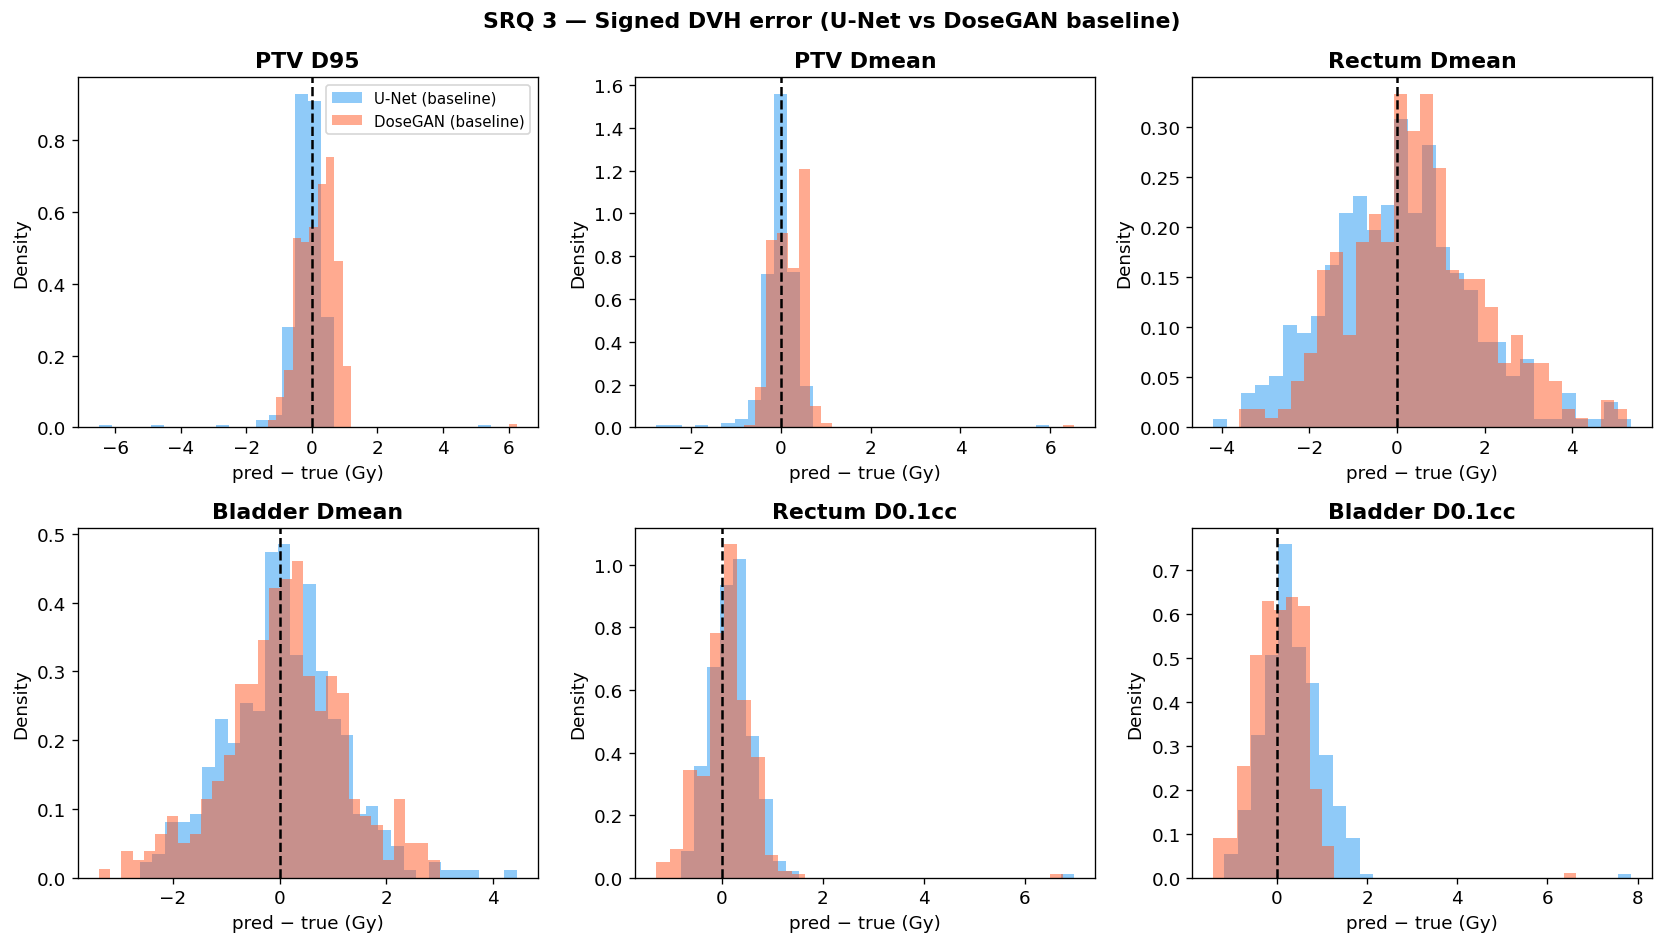

In [13]:
# Violin plot of signed DVH errors for baseline models
key_dvh = ['ptv_D95_diff', 'ptv_Dmean_diff', 'rectum_Dmean_diff',
           'bladder_Dmean_diff', 'rectum_D01cc_diff', 'bladder_D01cc_diff']
dvh_label_map = {
    'ptv_D95_diff':      'PTV D95',
    'ptv_Dmean_diff':    'PTV Dmean',
    'rectum_Dmean_diff': 'Rectum Dmean',
    'bladder_Dmean_diff':'Bladder Dmean',
    'rectum_D01cc_diff': 'Rectum D0.1cc',
    'bladder_D01cc_diff':'Bladder D0.1cc',
}

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, col in zip(axes.flat, key_dvh):
    for cond, df, color in [
        ('unet_base', unet_base, COLORS['unet_base']),
        ('dgan_base', dgan_base, COLORS['dgan_base']),
    ]:
        if col not in df.columns:
            continue
        vals = df[col].dropna()
        ax.hist(vals, bins=30, color=color, alpha=0.5, density=True, label=LABELS[cond])
    ax.axvline(0, color='black', linewidth=1.5, linestyle='--')
    ax.set_title(dvh_label_map[col], fontweight='bold')
    ax.set_xlabel('pred − true (Gy)')
    ax.set_ylabel('Density')

axes.flat[0].legend(fontsize=9)
fig.suptitle('SRQ 3 — Signed DVH error (U-Net vs DoseGAN baseline)', fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
# Gamma pass rates
gamma_cols = ['gamma_3pct_3mm', 'gamma_2pct_2mm']

print('SRQ 3 — Gamma pass rates (fold-mean ± fold-std)')
print('(reported as fraction of voxels passing; 1.0 = 100% pass rate)\n')

rows = []
for label, df in [
    ('U-Net baseline', unet_base), ('DoseGAN baseline', dgan_base),
    ('U-Net + geom',   unet_geom), ('DoseGAN + geom',   dgan_geom),
]:
    row = {'condition': label}
    for col in gamma_cols:
        if col in df.columns:
            valid = df[col].dropna()
            n_valid = len(valid)
            n_total = len(df)
            m = df.dropna(subset=[col]).groupby('_fold')[col].mean()
            row[col] = f'{m.mean():.4f} ± {m.std():.4f}  (n={n_valid}/{n_total})'
        else:
            row[col] = 'N/A'
    rows.append(row)

display(pd.DataFrame(rows).set_index('condition'))

SRQ 3 — Gamma pass rates (fold-mean ± fold-std)
(reported as fraction of voxels passing; 1.0 = 100% pass rate)



,gamma_3pct_3mm,gamma_2pct_2mm
condition,,
U-Net baseline,nan ± nan (n=0/367),nan ± nan (n=0/367)
DoseGAN baseline,nan ± nan (n=0/367),nan ± nan (n=0/367)
U-Net + geom,nan ± nan (n=0/367),nan ± nan (n=0/367)
DoseGAN + geom,nan ± nan (n=0/368),nan ± nan (n=0/368)


In [15]:
# Isodose surface metrics (Dice and HD95)
isodose_cols = [
    'Dice_100iso', 'HD95_100iso_mm',
    'Dice_95iso',  'HD95_95iso_mm',
    'Dice_80iso',  'HD95_80iso_mm',
    'Dice_50iso',  'HD95_50iso_mm',
]

print('SRQ 3 — Isodose surface Dice / HD95 (fold-mean ± fold-std)')
print('(100% / 95% / 80% / 50% of prescription dose surfaces)\n')

tbl3b = summary_table(
    [
        ('U-Net baseline', unet_base),
        ('DoseGAN baseline', dgan_base),
        ('U-Net + geom',  unet_geom),
        ('DoseGAN + geom', dgan_geom),
    ],
    isodose_cols
)
display(tbl3b)

SRQ 3 — Isodose surface Dice / HD95 (fold-mean ± fold-std)
(100% / 95% / 80% / 50% of prescription dose surfaces)



,Dice_100iso,HD95_100iso_mm,Dice_95iso,HD95_95iso_mm,Dice_80iso,HD95_80iso_mm,Dice_50iso,HD95_50iso_mm
condition,,,,,,,,
U-Net baseline,0.014 ± 0.001,267.105 ± 0.765,0.016 ± 0.001,265.339 ± 0.836,0.021 ± 0.001,260.903 ± 0.897,0.043 ± 0.003,233.687 ± 1.723
DoseGAN baseline,0.898 ± 0.141,50.949 ± 109.921,0.848 ± 0.262,54.753 ± 113.303,0.594 ± 0.386,150.468 ± 135.034,0.239 ± 0.232,236.492 ± 3.222
U-Net + geom,0.013 ± 0.001,266.310 ± 0.452,0.015 ± 0.001,264.582 ± 0.431,0.020 ± 0.002,259.879 ± 0.474,0.041 ± 0.005,232.461 ± 1.443
DoseGAN + geom,0.962 ± 0.003,1.823 ± 0.097,0.965 ± 0.001,1.836 ± 0.069,0.906 ± 0.105,32.257 ± 65.842,0.732 ± 0.345,56.042 ± 101.297


---
## Supporting Analysis A — Sigmoid vs Tanh activation ablation

**Purpose:** Justifies the choice of Sigmoid output activation for both models.  
GhTara (the reference DoseGAN implementation) uses Tanh. This ablation empirically determined which activation is better for this dataset.

**Result:** Sigmoid wins on all 10 fold-model combinations (~4% lower mean body MAE, lower fold variance).

In [16]:
ablation_metrics = ['body_MAE_Gy', 'body_RMSE_Gy', 'ptv_MAE_Gy']

if len(unet_tanh) > 0 and len(dgan_tanh) > 0:
    tbl_ab = summary_table(
        [
            ('U-Net — Sigmoid', unet_base),
            ('U-Net — Tanh',    unet_tanh),
            ('DoseGAN — Sigmoid', dgan_base),
            ('DoseGAN — Tanh',    dgan_tanh),
        ],
        ablation_metrics
    )
    print('Supporting A — Sigmoid vs Tanh (fold-mean ± fold-std, 5 folds)')
    display(tbl_ab)
else:
    print('Tanh ablation data not found — skipping.')

Supporting A — Sigmoid vs Tanh (fold-mean ± fold-std, 5 folds)


,body_MAE_Gy,body_RMSE_Gy,ptv_MAE_Gy
condition,,,
U-Net — Sigmoid,0.861 ± 0.026,1.514 ± 0.038,0.515 ± 0.123
U-Net — Tanh,0.895 ± 0.041,1.670 ± 0.050,N/A
DoseGAN — Sigmoid,0.868 ± 0.035,1.522 ± 0.045,0.474 ± 0.121
DoseGAN — Tanh,0.912 ± 0.065,1.582 ± 0.093,N/A


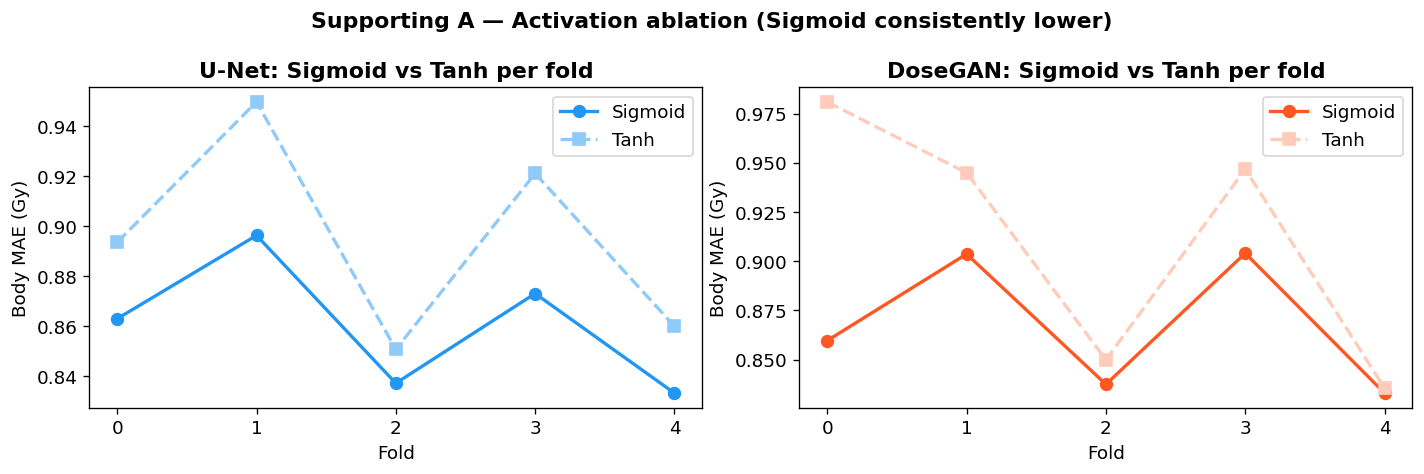

In [17]:
if len(unet_tanh) > 0 and len(dgan_tanh) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    for ax, (model_label, sig_df, tanh_df, sig_color, tanh_color) in zip(axes, [
        ('U-Net',   unet_base, unet_tanh, COLORS['unet_base'], COLORS['unet_tanh']),
        ('DoseGAN', dgan_base, dgan_tanh, COLORS['dgan_base'], COLORS['dgan_tanh']),
    ]):
        for df, color, ls, marker, label in [
            (sig_df,  sig_color,  '-', 'o', 'Sigmoid'),
            (tanh_df, tanh_color, '--', 's', 'Tanh'),
        ]:
            folds = df.groupby('_fold')['body_MAE_Gy'].mean()
            ax.plot(folds.index, folds.values, marker=marker, color=color,
                    linestyle=ls, linewidth=2, markersize=7, label=label)

        ax.set_xlabel('Fold')
        ax.set_ylabel('Body MAE (Gy)')
        ax.set_title(f'{model_label}: Sigmoid vs Tanh per fold', fontweight='bold')
        ax.set_xticks([0, 1, 2, 3, 4])
        ax.legend()

    fig.suptitle('Supporting A — Activation ablation (Sigmoid consistently lower)',
                 fontweight='bold')
    plt.tight_layout()
    plt.show()

---
## Supporting Analysis B — Acquisition group robustness (Inv1)

**Background:** The LUND-PROBE cohort contains two acquisition groups (oldAcq / newAcq) with different scanner protocols, as documented by Rogowski et al. (2025). EDA confirmed intensity and spacing differences.

**Finding (Inv1):** Mann-Whitney U test shows no statistically significant mean body MAE difference (p ≈ 0.89), but oldAcq patients dominate the worst-error tail. This is a *tail-risk inflation* pattern, not a mean shift.

In [18]:
print('Supporting B — Mann-Whitney U test: oldAcq vs newAcq body_MAE\n')

for label, df in [
    ('U-Net baseline', unet_base), ('DoseGAN baseline', dgan_base),
    ('U-Net + geom',   unet_geom), ('DoseGAN + geom',   dgan_geom),
]:
    old = df[df['acquisition_group'] == 'oldAcq']['body_MAE_Gy']
    new = df[df['acquisition_group'] == 'newAcq']['body_MAE_Gy']
    u, p = stats.mannwhitneyu(old, new, alternative='two-sided')
    print(f'{label}:')
    print(f'  oldAcq (n={len(old)}): mean={old.mean():.3f}  p90={old.quantile(0.9):.3f}  p99={old.quantile(0.99):.3f}')
    print(f'  newAcq (n={len(new)}): mean={new.mean():.3f}  p90={new.quantile(0.9):.3f}  p99={new.quantile(0.99):.3f}')
    print(f'  MWU p = {p:.4f}  → {"significant" if p < 0.05 else "not significant"}\n')

Supporting B — Mann-Whitney U test: oldAcq vs newAcq body_MAE

U-Net baseline:
  oldAcq (n=274): mean=0.867  p90=1.143  p99=1.592
  newAcq (n=93): mean=0.841  p90=1.020  p99=1.215
  MWU p = 0.8943  → not significant

DoseGAN baseline:
  oldAcq (n=274): mean=0.875  p90=1.203  p99=1.646
  newAcq (n=93): mean=0.845  p90=1.050  p99=1.377
  MWU p = 0.8934  → not significant

U-Net + geom:
  oldAcq (n=274): mean=0.845  p90=1.066  p99=1.513
  newAcq (n=93): mean=0.823  p90=0.986  p99=1.193
  MWU p = 0.7925  → not significant

DoseGAN + geom:
  oldAcq (n=274): mean=0.871  p90=1.077  p99=1.491
  newAcq (n=93): mean=0.861  p90=1.082  p99=1.302
  MWU p = 0.8889  → not significant



In [19]:
# Tail-risk analysis: what fraction of worst-N patients are oldAcq?
print('Supporting B — oldAcq concentration in worst-error patients (U-Net baseline)\n')
overall_old_frac = (unet_base['acquisition_group'] == 'oldAcq').mean()
print(f'Overall oldAcq fraction in dataset: {overall_old_frac:.1%}\n')

for n in [10, 20, 30, 50]:
    worst_n = unet_base.nlargest(n, 'body_MAE_Gy')
    old_frac = (worst_n['acquisition_group'] == 'oldAcq').mean()
    print(f'  Top {n:3d} worst patients: {old_frac:.1%} oldAcq  '
          f'(expected {overall_old_frac:.1%} under null)')

Supporting B — oldAcq concentration in worst-error patients (U-Net baseline)

Overall oldAcq fraction in dataset: 74.7%

  Top  10 worst patients: 100.0% oldAcq  (expected 74.7% under null)
  Top  20 worst patients: 100.0% oldAcq  (expected 74.7% under null)
  Top  30 worst patients: 83.3% oldAcq  (expected 74.7% under null)
  Top  50 worst patients: 88.0% oldAcq  (expected 74.7% under null)


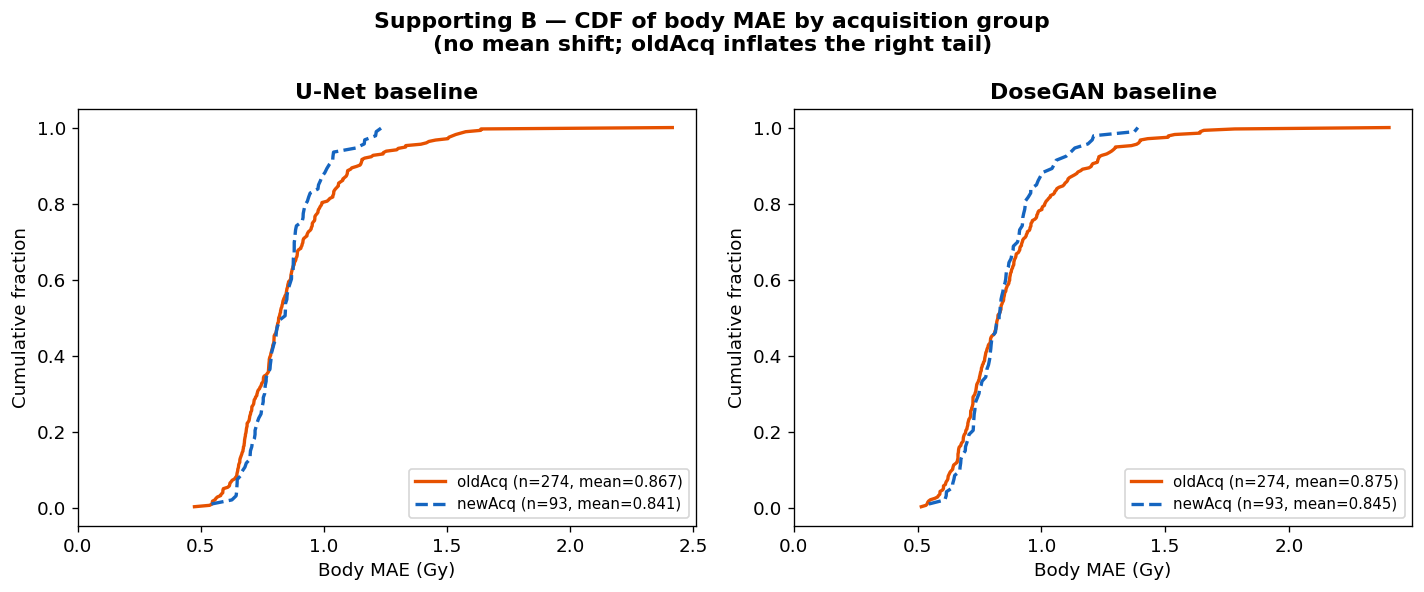

In [20]:
# CDF plot: oldAcq vs newAcq for both baseline models
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (label, df) in zip(axes, [
    ('U-Net baseline', unet_base),
    ('DoseGAN baseline', dgan_base),
]):
    for grp, color, ls in [('oldAcq', '#E65100', '-'), ('newAcq', '#1565C0', '--')]:
        vals = df[df['acquisition_group'] == grp]['body_MAE_Gy'].sort_values()
        cdf  = np.arange(1, len(vals) + 1) / len(vals)
        ax.plot(vals, cdf, color=color, linestyle=ls, linewidth=2,
                label=f'{grp} (n={len(vals)}, mean={vals.mean():.3f})')
    ax.set_xlabel('Body MAE (Gy)')
    ax.set_ylabel('Cumulative fraction')
    ax.set_title(f'{label}', fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_xlim(left=0)

fig.suptitle('Supporting B — CDF of body MAE by acquisition group\n'
             '(no mean shift; oldAcq inflates the right tail)', fontweight='bold')
plt.tight_layout()
plt.show()

---
## Summary of Results

In [21]:
print('=== RESULTS SUMMARY ===\n')

print('SRQ 1 — U-Net vs DoseGAN (baseline, Sigmoid, 5-fold CV):')
for label, df in [('U-Net', unet_base), ('DoseGAN', dgan_base)]:
    print(f'  {label}: body_MAE = {fold_mean(df,"body_MAE_Gy"):.3f} ± {fold_std(df,"body_MAE_Gy"):.3f} Gy  '
          f'| RMSE = {fold_mean(df,"body_RMSE_Gy"):.3f} Gy')
paired_tmp = unet_base[['patient_id','body_MAE_Gy']].merge(
    dgan_base[['patient_id','body_MAE_Gy']], on='patient_id', suffixes=('_u','_d'))
_, p_srq1 = stats.wilcoxon(paired_tmp['body_MAE_Gy_u'], paired_tmp['body_MAE_Gy_d'])
print(f'  Wilcoxon p = {p_srq1:.4f}  '
      f'U-Net lower on {(paired_tmp.body_MAE_Gy_u < paired_tmp.body_MAE_Gy_d).sum()}/{len(paired_tmp)} patients')

print()
print('SRQ 2 — Geometric channels effect (geom − baseline, mean Δ body_MAE):')
print(f'  U-Net:   {un_delta["delta"].mean():+.4f} Gy  '
      f'({(un_delta["delta"]<0).sum()}/{len(un_delta)} patients improve)')
print(f'  DoseGAN: {dg_delta["delta"].mean():+.4f} Gy  '
      f'({(dg_delta["delta"]<0).sum()}/{len(dg_delta)} patients improve)')

print()
print('SRQ 3 — DVH bias (U-Net baseline, mean pred − true):')
for col, name in [('ptv_D95_diff','PTV D95'), ('rectum_D01cc_diff','Rectum D0.1cc'),
                  ('bladder_D01cc_diff','Bladder D0.1cc')]:
    v = unet_base[col].dropna()
    print(f'  {name}: {v.mean():+.3f} Gy  ({(v>0).mean()*100:.0f}% over-predicting)')

print()
print('Supporting B — Acquisition group tail risk (U-Net baseline):')
worst_20 = unet_base.nlargest(20, 'body_MAE_Gy')
old_frac_20 = (worst_20['acquisition_group']=='oldAcq').mean()
overall_old = (unet_base['acquisition_group']=='oldAcq').mean()
print(f'  Overall oldAcq fraction: {overall_old:.1%}')
print(f'  Worst-20 oldAcq fraction: {old_frac_20:.1%}  (MWU body_MAE p ≈ 0.89 — no mean shift)')

=== RESULTS SUMMARY ===

SRQ 1 — U-Net vs DoseGAN (baseline, Sigmoid, 5-fold CV):
  U-Net: body_MAE = 0.861 ± 0.026 Gy  | RMSE = 1.514 Gy
  DoseGAN: body_MAE = 0.868 ± 0.035 Gy  | RMSE = 1.522 Gy
  Wilcoxon p = 0.0902  U-Net lower on 191/367 patients

SRQ 2 — Geometric channels effect (geom − baseline, mean Δ body_MAE):
  U-Net:   -0.0212 Gy  (195/367 patients improve)
  DoseGAN: +0.0006 Gy  (153/367 patients improve)

SRQ 3 — DVH bias (U-Net baseline, mean pred − true):
  PTV D95: -0.165 Gy  (34% over-predicting)
  Rectum D0.1cc: +0.216 Gy  (70% over-predicting)
  Bladder D0.1cc: +0.347 Gy  (71% over-predicting)

Supporting B — Acquisition group tail risk (U-Net baseline):
  Overall oldAcq fraction: 74.7%
  Worst-20 oldAcq fraction: 100.0%  (MWU body_MAE p ≈ 0.89 — no mean shift)
